# Part B

# Team
- Stefanos Panteli UC1065916<br>
spante01@ucy.ac.cy

- Evangelia Krigkou UC1067400<br>
ekrigk01@ucy.ac.cy

- Rafael Chrysanthou UC1064747<br>
rchrys03@ucy.ac.cy


GitHub: [https://github.com/stefanosPanteli/EPL445](https://github.com/stefanosPanteli/EPL445)

# Installs

In [ ]:
!pip install opencv-python
!pip install matplotlib
!pip install numpy

# Imports

In [3]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
import math

# Functions & Constants

In [ ]:
def plot_all(I, mask, magnitude_spectrum, I_inv, title: str):
    magnitude_spectrum_filterred = magnitude_spectrum * mask

    plt.subplot(221), plt.imshow(I, cmap= 'gray')
    plt.title('Input Image')
    plt.subplot(222), plt.imshow(mask, cmap= 'gray')
    plt.title(f'{title} Mask')
    plt.subplot(223), plt.imshow(magnitude_spectrum_filterred, cmap= 'gray'), plt.colorbar(fraction= 0.045, pad= 0.05)
    plt.title('Magnitude Spectrum\n(after Applying Mask)')
    plt.subplot(224), plt.imshow(I_inv, cmap= 'gray')
    plt.title('Inverse FFT')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(2,2))
    plt.imshow(magnitude_spectrum)
    plt.imshow(mask, alpha= 0.1)
    plt.title('Magnitude Spectrum\nand Mask on Top')
    plt.show()
    print()

# 1

In [ ]:
# def calc_cos(M: float, N: int, u: int, v: int, i: int, j: int):
#   return M * (1 + math.cos((2*math.pi/N) * (u*i + v*j)))
# N = ...
# cos_8_6 = lambda i, j: calc_cos(0.5, N, 8, 6, i, j)
# cos_4_2 = lambda i, j: calc_cos(1.5, N, 4, 2, i, j)
# cos_0_2 = lambda i, j: calc_cos(1.0, N, 0, 2, i, j)
# I = np.zeros((N,N))
# I[i,j] = cos_8_6(i, j) + cos_4_2(i, j) + cos_0_2(i, j) for i in range(0,N) for j in range(0,N)


N = 64
two_pi_over_n = (2 * math.pi) / N

I = np.zeros((N, N))
# Fill in image I with the 3 cosine waves
for i in range(0, N):
    for j in range(0, N):
        I[i, j] = 0.5 * (1 + math.cos(two_pi_over_n * (8*i + 6*j))) + \
                  1.5 * (1 + math.cos(two_pi_over_n * (4*i + 2*j))) + \
                  1.0 * (1 + math.cos(two_pi_over_n * (      2*j)))

# 2

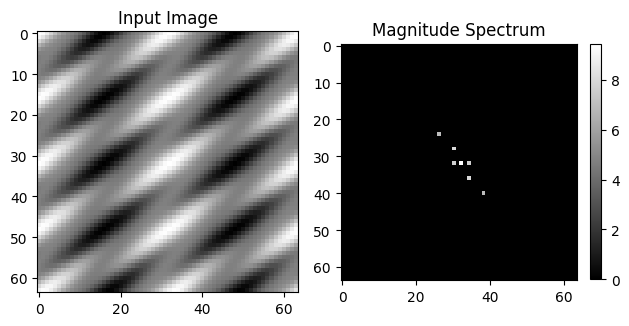

In [63]:
# Apply FFT transformation
I_fft = np.fft.fft2(I)
I_shift = np.fft.fftshift(I_fft)
magnitude_spectrum = np.log(1 + np.abs(I_shift))

# Show all 3
plt.subplot(121), plt.imshow(I, cmap= 'gray')
plt.title('Input Image')
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap= 'gray'),
plt.colorbar(fraction= 0.045, pad= 0.05)
plt.title('Magnitude Spectrum')
plt.tight_layout()
plt.show()

# 3

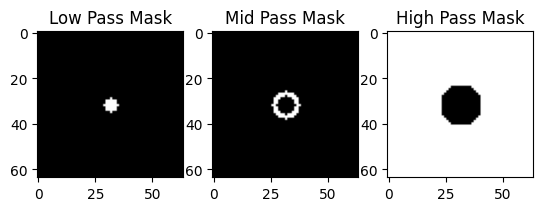

In [82]:
# Get shape
rows, cols = I.shape
crow, ccol = rows/2 , cols/2
crow = int(crow)
ccol = int(ccol)

# Define radiuses
low_radius: int = 3
mid_radius_outer: int = 6
mid_radius_inner: int = 4
high_radius: int = 9

# Circle Low Pass Mask
low_mask = np.zeros((rows, cols), np.uint8)
# low_mask[ # Square
#    crow - low_radius : crow + low_radius,
#    ccol - low_radius : ccol + low_radius
# ] = 1
for i in range(0, rows):
  for j in range(0, cols):
    if (i - crow)**2 + (j - ccol)**2 <= low_radius**2:
      low_mask[i, j] = 1

# Circle Mid Pass Mask
mid_mask = np.zeros((rows, cols), np.uint8)
# mid_mask[ # Square
#    crow - mid_radius_outer : crow + mid_radius_outer,
#    ccol - mid_radius_outer : ccol + mid_radius_outer
# ] = 1
# mid_mask[ # Square
#    crow - mid_radius_inner : crow + mid_radius_inner,
#    ccol - mid_radius_inner : ccol + mid_radius_inner
# ] = 0
for i in range(0, rows):
  for j in range(0, cols):
    if (i - crow)**2 + (j - ccol)**2 <= mid_radius_outer**2:
      mid_mask[i, j] = 1
for i in range(0, rows):
  for j in range(0, cols):
    if (i - crow)**2 + (j - ccol)**2 <= mid_radius_inner**2:
      mid_mask[i, j] = 0

# Circle High Pass Mask
high_mask = np.zeros((rows, cols), np.uint8)
# high_mask = np.ones((rows, cols), np.uint8)
# high_mask[ # Square
#    crow - high_radius : crow + high_radius,
#    ccol - high_radius : ccol + high_radius
# ] = 0
for i in range(0, rows):
  for j in range(0, cols):
    if (i - crow)**2 + (j - ccol)**2 >= high_radius**2:
      high_mask[i, j] = 1

# Showing Masks
plt.subplot(131), plt.imshow(low_mask, cmap= 'gray')
plt.title('Low Pass Mask')
plt.subplot(132), plt.imshow(mid_mask, cmap= 'gray')
plt.title('Mid Pass Mask')
plt.subplot(133), plt.imshow(high_mask, cmap= 'gray')
plt.title('High Pass Mask')
plt.show()

# 4

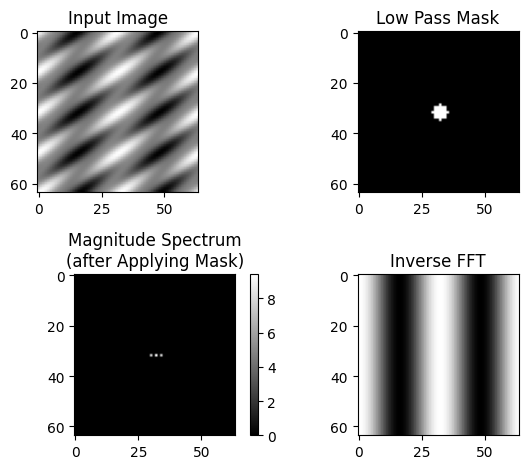

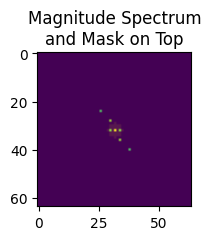

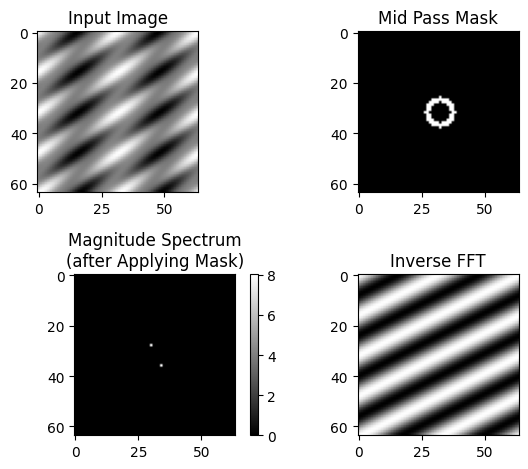

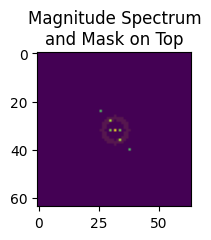

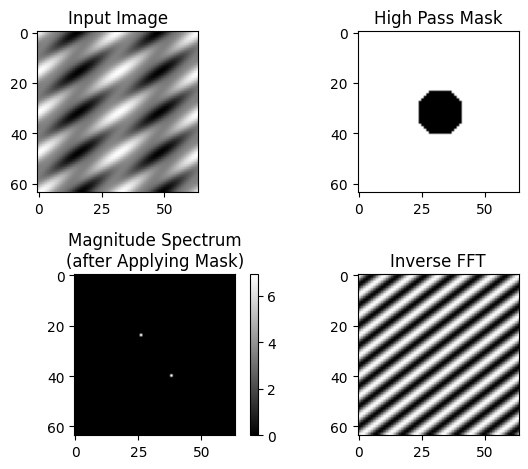

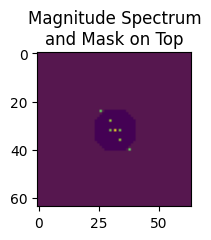

In [87]:
# Apply Low Filter & InverseFFT
low_I = I_shift * low_mask
low_I = np.fft.ifftshift(low_I)
low_I = np.fft.ifft2(low_I)
low_I = np.real(low_I)

# Apply Mid Filter & InverseFFT
mid_I = I_shift * mid_mask
mid_I = np.fft.ifftshift(mid_I)
mid_I = np.fft.ifft2(mid_I)
mid_I = np.real(mid_I)

# Apply High Filter & InverseFFT
high_I = I_shift * high_mask
high_I = np.fft.ifftshift(high_I)
high_I = np.fft.ifft2(high_I)
high_I = np.real(high_I)

# Show Low Pass
plot_all(I, low_mask, magnitude_spectrum, low_I, 'Low Pass')

# Show Mid Pass
plot_all(I, mid_mask, magnitude_spectrum, mid_I, 'Mid Pass')

# Show High Pass
plot_all(I, high_mask, magnitude_spectrum, high_I, 'High Pass')